In [1]:
import os
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from functools import reduce
from scipy.stats import linregress

In [9]:
markers = ["Dad2", "Sac6", "Tgl3", "Pex3", "Pil1", "Nuf2", "Snf7"]
phenotype_set = "Compartments" # Cells or Compartments
pen_col_to_select = "Overall_Penetrance"

#markers = ["Dad2", "Sac6", "Tgl3", "Pex3"]
#pen_cols_to_select = ["Overall_Penetrance", "Overall_Small_Penetrance", "Overall_Large_Penetrance", "Overall_Elongated_Penetrance", "Overall_Nonpolar_Penetrance"]


### Comparing Hits Between MPv1 and MPv2

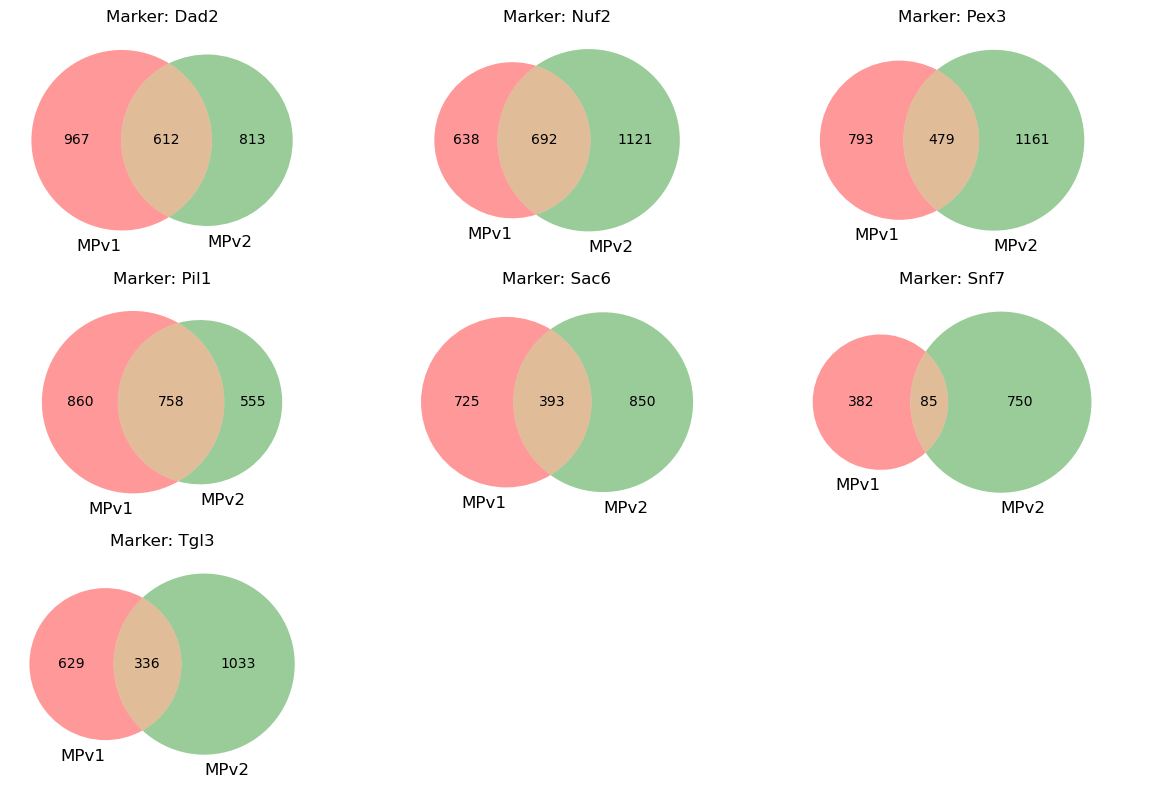

In [11]:
hit_dfs = []
for marker in markers:
    compartment_hits = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/Compartments/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .with_columns(pl.lit(marker).alias("Marker"))
        .select(["Marker", "Strain_ID"])
        )
    
    cell_hits = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/Cells/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .with_columns(pl.lit(marker).alias("Marker"))
        .select(["Marker", "Strain_ID"])
        )
    
    overall_hits = (
        pl
        .concat([compartment_hits, cell_hits], how="vertical")
        .unique()
    )
    
    hit_dfs.append(overall_hits)
    
mpv2_hits = (
    pl
    .concat(hit_dfs, how="vertical")
    .group_by("Marker")
    .agg(pl.col("Strain_ID").unique())
    .to_dict(as_series=False)
    )
mpv1_hits = (
    pl
    .read_csv("/mnt/c/Users/peree/OneDrive/Desktop/CompBio_Code/penetrance_pleiotropy_replicate_analysis/penetrance_data/aggregated_data/sheetE.csv")
    .select(["Marker", "Strain"])
    .rename({"Strain": "Strain_ID"})
    .filter(pl.col("Marker").is_in(markers))
    .group_by("Marker")
    .agg(pl.col("Strain_ID").unique())
    .to_dict(as_series=False)
    )

mpv2_dict = dict(zip(mpv2_hits["Marker"], mpv2_hits["Strain_ID"]))
mpv1_dict = dict(zip(mpv1_hits["Marker"], mpv1_hits["Strain_ID"]))

mpv2_dict = {k: set(v) for k, v in mpv2_dict.items()}
mpv1_dict = {k: set(v) for k, v in mpv1_dict.items()}

markers = sorted(set(mpv1_dict) | set(mpv2_dict))

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for i, marker in enumerate(markers):
    set1 = mpv1_dict.get(marker, set())
    set2 = mpv2_dict.get(marker, set())

    venn2([set1, set2], set_labels=("MPv1", "MPv2"), ax=axes[i])
    axes[i].set_title(f"Marker: {marker}")

# Hide unused subplot (since 5 plots in 2x3 grid)
for j in range(len(markers), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()
plt.close()

### Correlation Matrix

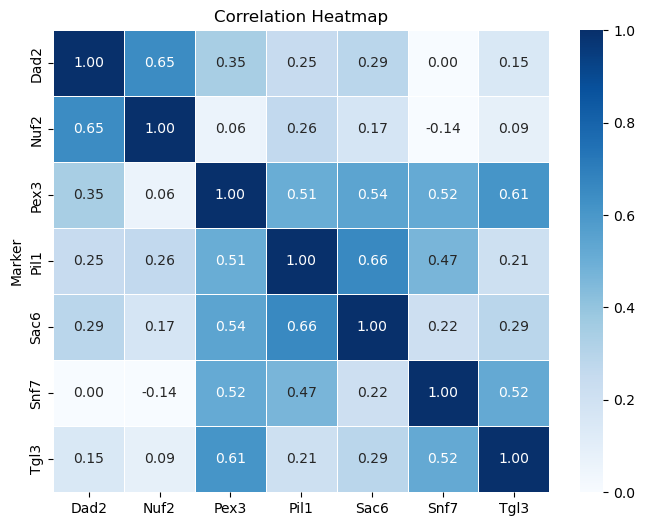

In [12]:
## Read data
marker_dfs = []
for marker in markers:
    #renamed_marker = {col: f"{marker}_{col}" for col in pen_cols_to_select}
    marker_df = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .select(["ORF", "Strain_ID"] + [pen_col_to_select])
        .filter(~pl.col("ORF").is_in(["YOR202W", "YMR271C"]))
        .rename({pen_col_to_select: marker})
        .drop("ORF")
        )
    marker_dfs.append(marker_df)

combined_df = marker_dfs[0]
for marker_df in marker_dfs[1:]:
    combined_df = combined_df.join(
        marker_df,
        on="Strain_ID",
        how="full",
        coalesce=True
    )


## Calculate correlations
numeric_df = combined_df.drop("Strain_ID")
corr_matrix = pl.DataFrame(
    {
        col1: [
            numeric_df.select(pl.corr(pl.col(col1), pl.col(col2))).item()
            for col2 in numeric_df.columns
        ]
        for col1 in numeric_df.columns
    }
)

corr_matrix = (
    corr_matrix
    .with_columns(pl.Series("Marker", numeric_df.columns))
    .select(["Marker"] + numeric_df.columns)
    .to_pandas()
    )

corr_matrix = corr_matrix.set_index("Marker")


## Plot
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, vmin=0, vmax=1, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()
plt.close()


### Penetrance Distributions

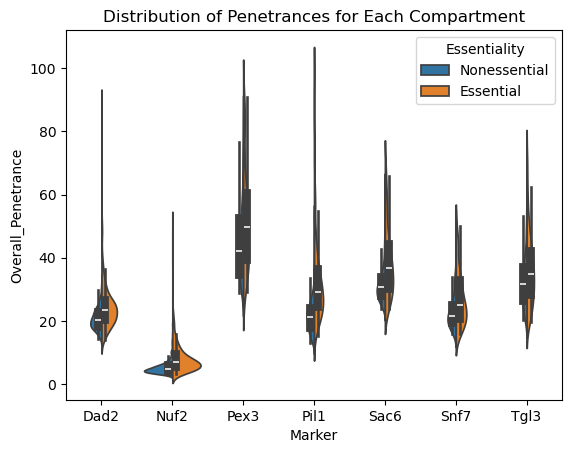

In [13]:
## Read data
marker_dfs = []
for marker in markers:
    #renamed_marker = {col: f"{marker}_{col}" for col in pen_cols_to_select}
    marker_df = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .with_columns(
            (pl.lit(marker).alias("Marker")),
            (
                pl
                .when(pl.col("Strain_ID").str.contains("tsa"))
                .then(pl.lit("Essential"))
                .otherwise(pl.lit("Nonessential"))
            ).alias("Essentiality"),
            (pl.col("Overall_Penetrance") * 100)
            )
        .select(["Marker", "ORF", "Strain_ID", "Essentiality"] + [pen_col_to_select])
        .filter(~pl.col("ORF").is_in(["YOR202W", "YMR271C"]))
        .drop("ORF")
        )
    marker_dfs.append(marker_df)

combined_df = pl.concat(marker_dfs, how="vertical")


# Plot
sns.violinplot(x="Marker", y="Overall_Penetrance", hue="Essentiality", data=combined_df, split=True)
plt.title("Distribution of Penetrances for Each Compartment")
plt.show()
plt.close()


### Replicate - Replicate Correlations

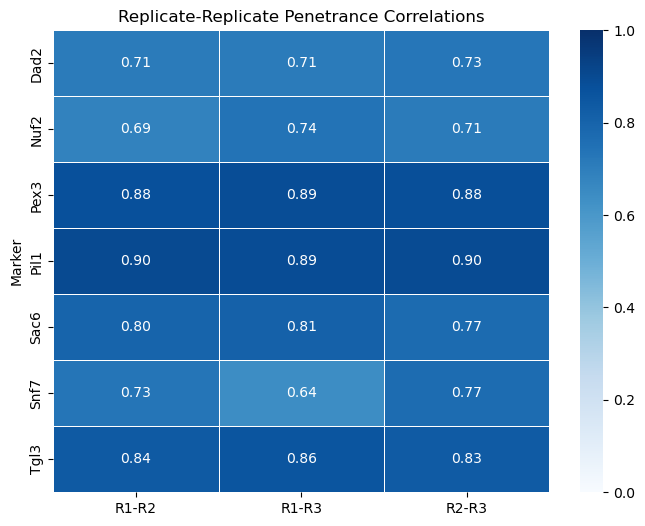

In [14]:
corr_matrices = []

for marker in markers:
    ## Read data
    #renamed_marker = {col: f"{marker}_{col}" for col in pen_cols_to_select}
    sheetD_strains = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .select("Strain_ID", "ORF")
        .drop("ORF")
        .to_series()
        .to_list()
        )
    
    marker_df = (
        pl
        .read_csv(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/per_replicate_penentrances_and_distances/{marker}_per_replicate_penetrances_and_distances.csv")
        .select(["ORF", "Strain_ID", "Penetrance_R1", "Penetrance_R2", "Penetrance_R3"])
        .filter(pl.col("Strain_ID").is_in(sheetD_strains))
        .rename({
            "Penetrance_R1": f"{marker}_R1",
            "Penetrance_R2": f"{marker}_R2",
            "Penetrance_R3": f"{marker}_R3",
            })
        .drop("ORF")
        )


    ## Calculate correlations
    numeric_df = marker_df.drop("Strain_ID")
    corr_matrix = pl.DataFrame(
        {
            col1: [
                numeric_df.select(pl.corr(pl.col(col1), pl.col(col2))).item()
                for col2 in numeric_df.columns
            ]
            for col1 in numeric_df.columns
        }
    )

    corr_matrix = (
        corr_matrix
        .with_columns(pl.Series("Marker", numeric_df.columns))
        .select(["Marker"] + numeric_df.columns)
        )
    
    corr_matrix_flat = (
        pl.DataFrame(
            {
                "Marker": marker,
                "R1-R2": corr_matrix[1,1],
                "R1-R3": corr_matrix[2,1],
                "R2-R3": corr_matrix[2,2]
                }
            )
        )

    corr_matrices.append(corr_matrix_flat)
    
corr_matrices = pl.concat(corr_matrices, how="vertical").to_pandas().set_index("Marker")

## Plot
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrices, vmin=0, vmax=1, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Replicate-Replicate Penetrance Correlations")
plt.show()
plt.close()

### Morphological Pleiotropy

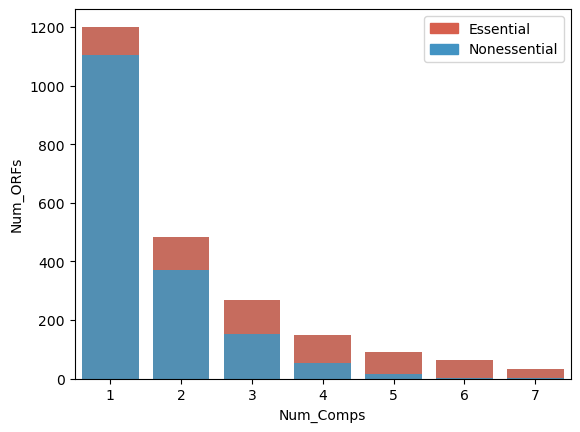

In [15]:
## Read data
phenotype_set = "Cells" # Cells or Compartments

marker_dfs = []
for marker in markers:
    marker_df = (
        pl
        .read_excel(f"/home/alex/alex_files/markerproject_redux/strain_filtering/{phenotype_set}/filtered_strain_workbooks/{marker}_filtered_strains.xlsx", sheet_name="SheetD")
        .with_columns(
            (pl.lit(marker).alias("Marker")),
            (
                pl
                .when(pl.col("Strain_ID").str.contains("tsa"))
                .then(pl.lit("Essential"))
                .otherwise(pl.lit("Nonessential"))
            ).alias("Essentiality"),
            (pl.col("Overall_Penetrance") * 100)
            )
        .select(["Marker", "ORF", "Essentiality"])
        .filter(~pl.col("ORF").is_in(["YOR202W", "YMR271C"]))
        )
    marker_dfs.append(marker_df)

combined_df = pl.concat(marker_dfs, how="vertical").unique()

combined_df_all = (
    combined_df
    .group_by("ORF", "Essentiality")
    .agg(pl.len().alias("Num_Comps"))
    .group_by("Num_Comps")
    .agg(pl.len().alias("Num_ORFs"))
)

combined_df_noness = (
    combined_df
    .filter(pl.col("Essentiality") == "Nonessential")
    .group_by("ORF")
    .agg(pl.len().alias("Num_Comps"))
    .group_by("Num_Comps")
    .agg(pl.len().alias("Num_ORFs"))
)

bar1 = sns.barplot(x="Num_Comps",  y="Num_ORFs", data=combined_df_all, color="#D75F4D")
bar2 = sns.barplot(x="Num_Comps",  y="Num_ORFs", data=combined_df_noness, estimator=sum, color="#4293C3")

# add legend
top_bar = mpatches.Patch(color="#D75F4D", label="Essential")
bottom_bar = mpatches.Patch(color="#4293C3", label="Nonessential")
plt.legend(handles=[top_bar, bottom_bar])